In [195]:
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.tsa.ar_model import AutoReg

from sys import path
path.append('../../wavelet/')
import cwt_segmentation as cs

In [175]:
ar = ArmaProcess([1, -1], [1])

In [216]:
t = np.arange(0, 50, 0.1)
x = ar.generate_sample(500) + 4 * np.cos(2*np.pi*0.5*t)

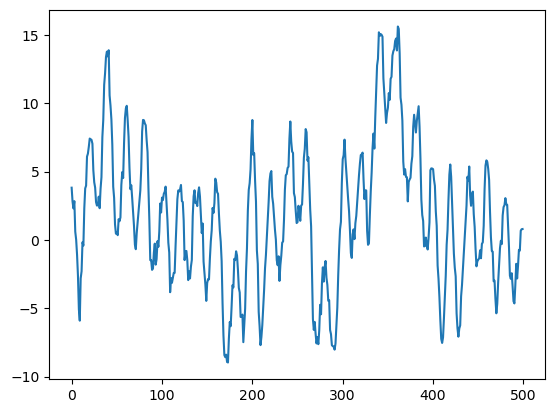

In [217]:
plt.plot(x)

In [218]:
model = AutoReg(x, lags=1)

In [219]:
res = model.fit()

print("Estimated coefficients:", res.params[1:])
print("Estimated sigma^2:    ", res.sigma2)

Estimated coefficients: [0.96627081]
Estimated sigma^2:     1.7524994974319201


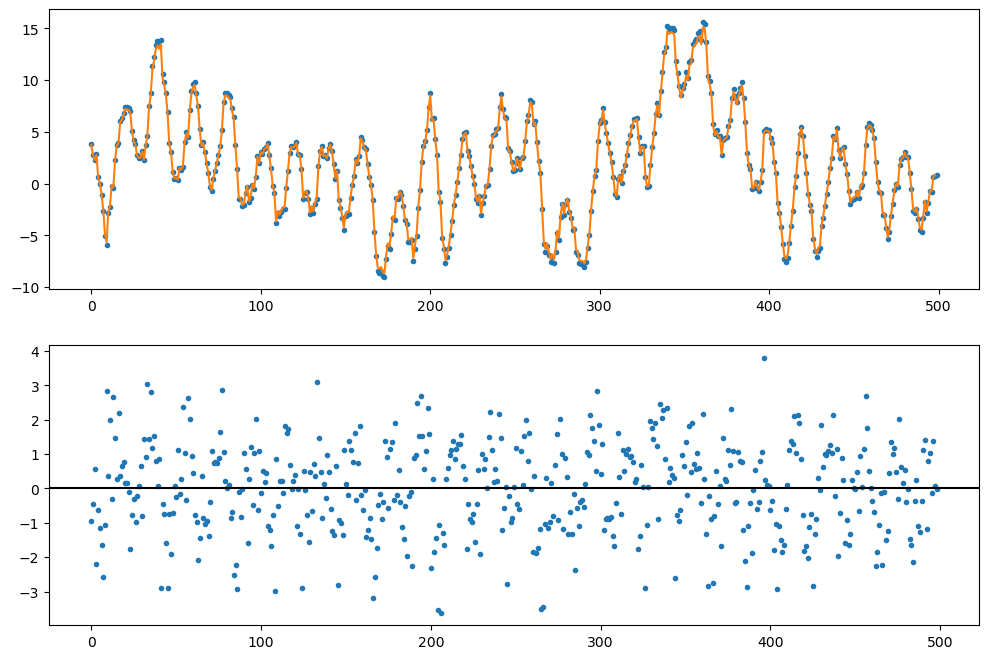

In [220]:
f, (ax,ax1) = plt.subplots(2,1, figsize=(12,8))

ax.plot(x, '.')
ax.plot(res.fittedvalues)
ax1.plot(res.resid, '.')
ax1.axhline(color='k')

## Fitting AR1 to data=AR1+cosine shows that the noise model completely overfits the oscillations


# Filter oscillations out before fitting AR1 model

In [221]:
x_filt = cs.remove_frequency_band(x, fs=10, fmin=0.2, fmax=1)

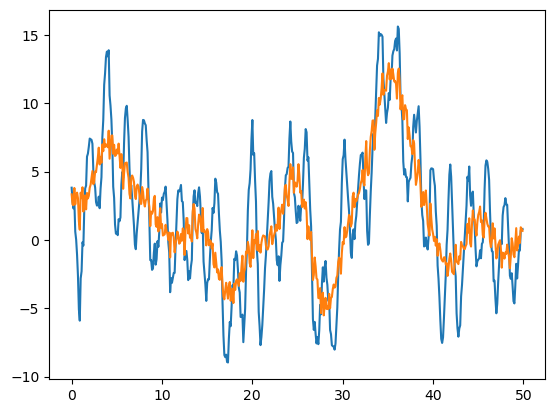

In [222]:
plt.plot(t, x)
plt.plot(t, x_filt)

In [229]:
model = AutoReg(x_filt, lags=1)

In [230]:
res = model.fit()

print("Estimated coefficients:", res.params[1:])
print("Estimated sigma^2:    ", res.sigma2)

Estimated coefficients: [0.97452412]
Estimated sigma^2:     0.739433221387933


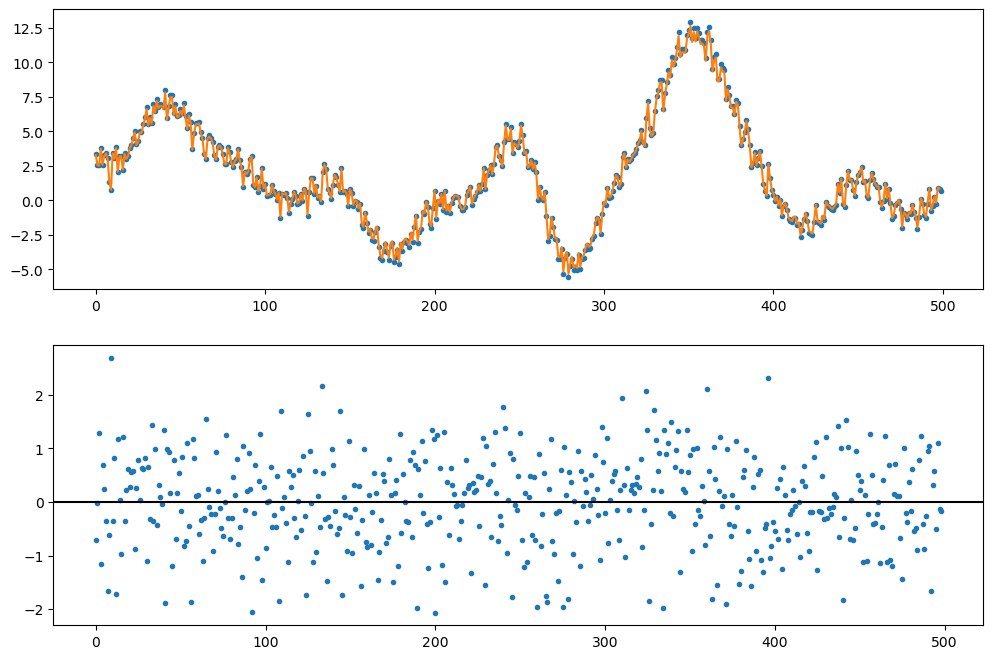

In [231]:
f, (ax,ax1) = plt.subplots(2,1, figsize=(12,8))

ax.plot(x_filt, '.')
ax.plot(res.fittedvalues)
ax1.plot(res.resid, '.')
ax1.axhline(color='k')